# Проект. Исследование стартапов

- Автор: Севрюкова В.Ю.
- Дата: 27.02.2026г.

## Введение


**Цель:** Провести исследовательский анализ данных финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компании.  
**Задача** — подготовить датасет к работе, исследовать динамику и структуру финансирования стартапов и ответить на вопросы, важные для оценки инвестиционных стратегий.
 В рамках проекта нам предстоит:
 * Провести предобработку данных, убрать дубликаты и пропуски, проверить корректность числовых и временных значений.
 * Выделить группы компаний по срокам финансирования и сравнить их по количеству и объёму инвестиций.
 * Классифицировать сегменты рынка на массовые, средние и нишевые и учесть это в дальнейшем анализе.
 * Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования.
 * Сравнить популярность и объёмы разных типов финансирования.
 * Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.
 * Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.
 * Подвести итоговые выводы и дать рекомендации, куда и каким образом было бы целесообразно инвестировать, если бы на дворе был 2015 год.


## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# Загружаем данные из zip-архива основного датасета
df_1 = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

In [3]:
# Загружаем данные дополнительного датасета
df_2 = pd.read_csv('https://code.s3.yandex.net/datasets/cb_returns.csv')

In [4]:
# Выводим первые строки датафрейма df_1 на экран
df_1.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Выводим информацию о датафрейме df_1 
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [6]:
# Выводим первые строки датафрейма df_2 на экран
df_2.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [7]:
# Выводим информацию о датафрейме df_2 
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [8]:
df_1.isna().sum()

name                     4857
homepage_url             8305
category_list            8817
 market                  8817
 funding_total_usd       4856
status                   6170
country_code            10129
state_code              24133
region                  10129
city                    10972
funding_rounds           4856
participants            23821
founded_at              15740
founded_month           15812
founded_quarter         15812
founded_year            15740
first_funding_at         4856
mid_funding_at          24006
last_funding_at          4856
seed                     4856
venture                  4856
equity_crowdfunding      4856
undisclosed              4856
convertible_note         4856
debt_financing           4856
angel                    4856
grant                    4856
private_equity           4856
post_ipo_equity          4856
post_ipo_debt            4856
secondary_market         4856
product_crowdfunding     4856
round_A                  4856
round_B   

In [9]:
# Доля пропусков
df_1.isna().mean()

name                    0.089457
homepage_url            0.152963
category_list           0.162394
 market                 0.162394
 funding_total_usd      0.089439
status                  0.113641
country_code            0.186558
state_code              0.444487
region                  0.186558
city                    0.202085
funding_rounds          0.089439
participants            0.438741
founded_at              0.289903
founded_month           0.291229
founded_quarter         0.291229
founded_year            0.289903
first_funding_at        0.089439
mid_funding_at          0.442148
last_funding_at         0.089439
seed                    0.089439
venture                 0.089439
equity_crowdfunding     0.089439
undisclosed             0.089439
convertible_note        0.089439
debt_financing          0.089439
angel                   0.089439
grant                   0.089439
private_equity          0.089439
post_ipo_equity         0.089439
post_ipo_debt           0.089439
secondary_

In [10]:
# Подсчитываем долю строк с пропусками
df_1.isna().sum()/df_1.shape[0]

name                    0.089457
homepage_url            0.152963
category_list           0.162394
 market                 0.162394
 funding_total_usd      0.089439
status                  0.113641
country_code            0.186558
state_code              0.444487
region                  0.186558
city                    0.202085
funding_rounds          0.089439
participants            0.438741
founded_at              0.289903
founded_month           0.291229
founded_quarter         0.291229
founded_year            0.289903
first_funding_at        0.089439
mid_funding_at          0.442148
last_funding_at         0.089439
seed                    0.089439
venture                 0.089439
equity_crowdfunding     0.089439
undisclosed             0.089439
convertible_note        0.089439
debt_financing          0.089439
angel                   0.089439
grant                   0.089439
private_equity          0.089439
post_ipo_equity         0.089439
post_ipo_debt           0.089439
secondary_

In [11]:
df_2.isna().sum()

year                    0
seed                    0
venture                 0
equity_crowdfunding     0
undisclosed             0
convertible_note        0
debt_financing          0
angel                   0
grant                   0
private_equity          0
post_ipo_equity         0
post_ipo_debt           0
secondary_market        0
product_crowdfunding    0
dtype: int64

Датасет /datasets/cb_investments.csv содержит 40 столбцов и 54294 строки, в который содержат информацию о компаниях и состоявшемся финансировании.
После первичного анализа данных можно сделать следующие выводы:

Названия столбцов лучше привести к одному виду, например snake case. Все представленные данные содержат числовые значения и текстовые, хранятся в типах данных int64, float64, object. Тип данных funding_total_usd, founded_at, founded_month, founded_year, first_funding_at, mid_funding_at, last_funding_at не соответствуют логическому типу данных, следует поменять на соответствующий. Пропуски содержатся во всех столбцах. Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.


Датасет /datasets/cb_returns.csv содержит 14 столбцов и 15 строк, который содержит информацию об объёмах возвратов по годам и типам финансирования в миллионах долларов.
После первичного анализа данных можно сделать следующие выводы:

Названия столбцов лучше привести к одному виду, например snake case. Все представленные данные содержат числовые значения и  хранятся в типах данных float64 и int64. Пропуски сотсутствуют. Тип данных в столбцах кажутся соответствующим.Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

In [12]:
# создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
temp_1 = df_1.copy() 
len(temp_1)

54294

In [13]:
print(f"Количество строк до обработки: {df_1.shape[0]}")

Количество строк до обработки: 54294


In [14]:
# создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
temp_2 = df_2.copy() 
len(temp_2)

15

### 1.2. Предобработка данных

In [15]:
# Проверим наименование столбцов датафрейма
df_1.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [16]:
# Приведим все столбцы к стилю snake case
df_1.columns = df_1.columns.str.lower().str.strip().str.replace(' ', '_')

In [17]:
# Проверим изменения
df_1.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_a', 'round_b',
       'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h'],
      dtype='object')

In [18]:
# Проверим наименование столбцов датафрейма
df_2.columns

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')

In [19]:
# Приведим все столбцы к стилю snake case
df_2.columns = df_2.columns.str.lower().str.replace(' ', '_').str.strip()

In [20]:
# Проверим изменения
df_2.columns

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')

In [21]:
# Выведим число пропусков
df_1['funding_total_usd'].isna().sum()

4856

In [22]:
# Выводим уникальные значения
df_1['funding_total_usd'].unique()

array([' 9,00,00,000 ', ' 20,00,000 ', ' 90,00,000 ', ..., ' 72,16,365 ',
       ' 5,60,248 ', nan], dtype=object)

In [23]:
# Проверим наличие пустых строк или др некорректных значений (которые могут вызыватть проблемы при преобразовании)
df_1['funding_total_usd'].astype(str).str.contains(r'[^\d.]')

0        True
1        True
2        True
3        True
4        True
         ... 
54289    True
54290    True
54291    True
54292    True
54293    True
Name: funding_total_usd, Length: 54294, dtype: bool

In [24]:
# Удаляем все нецифровые символы, кроме точки (приводим к строке и удаляем все, кроме точки)
df_1['funding_total_usd'] = (df_1['funding_total_usd']
                             .astype(str).
                             str.replace(r'[^\d.]', '', regex=True))                             

In [25]:
# Преобразуем в числовой тип
df_1['funding_total_usd'] = pd.to_numeric(df_1['funding_total_usd'],errors='coerce')

In [26]:
# Выводим уникальные значения
df_1['funding_total_usd'].unique()

array([9.000000e+07, 2.000000e+06, 9.000000e+06, ..., 5.897100e+04,
       7.216365e+06, 5.602480e+05])

In [27]:
# Проверим наличие пустых строк или др некорректных значений (которые могут вызыватть проблемы при преобразовании)
df_1['funding_total_usd'].astype(str).str.contains(r'[^\d.]')

0        False
1        False
2        False
3        False
4        False
         ...  
54289     True
54290     True
54291     True
54292     True
54293     True
Name: funding_total_usd, Length: 54294, dtype: bool

In [28]:
# Выведим строки с корректными числовыми значениями
df_1[~df_1['funding_total_usd'].astype(str).str.contains(r'[^\d.]')].head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,Harvard University,http://harvard.edu,|Education|,Education,90000000.0,operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,2000000.0,operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,540000.0,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
df_1['funding_total_usd'].head(20)

0      90000000.0
1       2000000.0
2       9000000.0
3       7700000.0
4        540000.0
5      19000000.0
6      12000000.0
7       8700000.0
8       6000000.0
9       3500000.0
10     28000000.0
11      2705000.0
12      8900000.0
13            NaN
14      8000000.0
15            NaN
16      3900000.0
17    750500000.0
18      2000000.0
19            NaN
Name: funding_total_usd, dtype: float64

In [30]:
df_1['funding_total_usd'].isna().sum()

13387

In [31]:
# Перечень столбцов, которые должны иметь тип данных даты и времени
numeric_columns = ['founded_at','founded_month','first_funding_at','mid_funding_at','last_funding_at']

In [32]:
# Преобразование типов данных и замена всех значений на NaN, которые не удалось преобразовать в тип данных даты и времени
for column in numeric_columns:
    df_1[column]= pd.to_datetime(df_1[column],errors='coerce')

In [33]:
# Проверим тип данных
df_1[['founded_at','founded_month','first_funding_at','mid_funding_at','last_funding_at']].dtypes

founded_at          datetime64[ns]
founded_month       datetime64[ns]
first_funding_at    datetime64[ns]
mid_funding_at      datetime64[ns]
last_funding_at     datetime64[ns]
dtype: object

В датасете `cb_returns` сделайте столбец `year` индексом всего датасета, если не делали это при загрузке.

In [34]:
df_2 = df_2.set_index('year')

Обработайте текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполните заглушками там, где это понадобится.

In [35]:
# Выводим информацию о датафрейме df_1 и определим столбцы с текстовыми данными
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  49437 non-null  object        
 1   homepage_url          45989 non-null  object        
 2   category_list         45477 non-null  object        
 3   market                45477 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                48124 non-null  object        
 6   country_code          44165 non-null  object        
 7   state_code            30161 non-null  object        
 8   region                44165 non-null  object        
 9   city                  43322 non-null  object        
 10  funding_rounds        49438 non-null  float64       
 11  participants          30473 non-null  float64       
 12  founded_at            38553 non-null  datetime64[ns]
 13  founded_month   

In [36]:
# Перечень столбцов с текстовыми данными, которые мы будем обрабатывать 
columns_to_fill = ['name', 'homepage_url', 'category_list','market','status','country_code','state_code','region','city','founded_quarter']


In [37]:
# Заполняем пропуски в указанных столбцах и ставим 'загрушки'
df_1[columns_to_fill] = df_1[columns_to_fill].fillna('заглушка')

In [38]:
# Проверим содержание столбцов после заполения пропусков 'заглушками'
df_1[columns_to_fill]

,name,homepage_url,category_list,market,status,country_code,state_code,region,city,founded_quarter
0,Harvard University,http://harvard.edu,|Education|,Education,operating,USA,MA,Boston,Cambridge,заглушка
1,University of New Brunswick,http://www.unb.ca,заглушка,заглушка,operating,заглушка,заглушка,заглушка,заглушка,заглушка
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,operating,USA,DE,"Wilmington, Delaware",Wilmington,заглушка
3,University of Michigan,http://www.umich.edu/,|Education|,Education,operating,USA,MI,Detroit,Ann Arbor,заглушка
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,operating,USA,OH,Cleveland,Cleveland,заглушка
...,...,...,...,...,...,...,...,...,...,...
54289,заглушка,заглушка,заглушка,заглушка,заглушка,заглушка,заглушка,заглушка,заглушка,заглушка
54290,заглушка,заглушка,заглушка,заглушка,заглушка,заглушка,заглушка,заглушка,заглушка,заглушка
54291,заглушка,заглушка,заглушка,заглушка,заглушка,заглушка,заглушка,заглушка,заглушка,заглушка
54292,заглушка,заглушка,заглушка,заглушка,заглушка,заглушка,заглушка,заглушка,заглушка,заглушка


In [39]:
# Находим полные дубликаты
дубликаты = df_1[df_1.duplicated()]

In [40]:
# Выводим количество дубликатов
количество_дубликатов = df_1.duplicated().sum()
print(f"Количество дубликатов: {количество_дубликатов}")

Количество дубликатов: 4855


In [41]:
# Отображаем сами дубликаты
print(дубликаты)

           name homepage_url category_list    market  funding_total_usd  \
49439  заглушка     заглушка      заглушка  заглушка                NaN   
49440  заглушка     заглушка      заглушка  заглушка                NaN   
49441  заглушка     заглушка      заглушка  заглушка                NaN   
49442  заглушка     заглушка      заглушка  заглушка                NaN   
49443  заглушка     заглушка      заглушка  заглушка                NaN   
...         ...          ...           ...       ...                ...   
54289  заглушка     заглушка      заглушка  заглушка                NaN   
54290  заглушка     заглушка      заглушка  заглушка                NaN   
54291  заглушка     заглушка      заглушка  заглушка                NaN   
54292  заглушка     заглушка      заглушка  заглушка                NaN   
54293  заглушка     заглушка      заглушка  заглушка                NaN   

         status country_code state_code    region      city  ...  \
49439  заглушка     заглушка   

In [42]:
# Определим количество дубликатов
количество_дубликатов = df_2.duplicated().sum()
print(f"Количество дубликатов: {количество_дубликатов}")

Количество дубликатов: 0


In [43]:
# Удалим дубликаты из датафрейма
df_1 = df_1.drop_duplicates()

In [44]:
# Проверим количество дубликатов после удаления
количество_дубликатов = df_1.duplicated().sum()
print(f"Количество дубликатов: {количество_дубликатов}")

Количество дубликатов: 0


In [45]:
# Перечень столбцов, которые должны иметь тип данных даты и времени
numeric_columns = ['first_funding_at','last_funding_at','mid_funding_at']

In [46]:
# Преобразование типов данных и замена всех значений на NaN, которые не удалось преобразовать в тип данных даты и времени
for column in numeric_columns:
    df_1.loc[:, column] = pd.to_datetime(df_1[column], errors='coerce')

In [47]:
# Рассчитываем mid_funding_at как середину между first_funding_at и last_funding_at
df_1['mid_funding_at'] = df_1['mid_funding_at'].combine_first(df_1['first_funding_at'] + (df_1['last_funding_at'] - df_1['first_funding_at']) / 2
)

In [48]:
# Проверяем количество оставшихся пропусков в mid_funding_at
df_1['mid_funding_at'].isna().sum()

9

In [49]:
df_1['mid_funding_at'].head()

0   2014-01-06
1   2014-05-15
2   2009-07-02
3   2013-11-21
4   2014-01-14
Name: mid_funding_at, dtype: datetime64[ns]

In [50]:
df_1['first_funding_at'].head()

0   2014-01-06
1   2014-05-15
2   2009-07-02
3   2013-11-21
4   2014-01-14
Name: first_funding_at, dtype: datetime64[ns]

In [51]:
df_1['last_funding_at'].head()

0   2014-01-06
1   2014-05-15
2   2009-07-02
3   2014-11-03
4   2014-01-14
Name: last_funding_at, dtype: datetime64[ns]

In [52]:
# Проверрим после изменения
df_1['mid_funding_at'].head()

0   2014-01-06
1   2014-05-15
2   2009-07-02
3   2013-11-21
4   2014-01-14
Name: mid_funding_at, dtype: datetime64[ns]

В ходе анализа данных были выявлены пропуски в столбцах: funding_total_usd, participants, founded_at, founded_month, founded_year, first_funding_at, mid_funding_at, last_funding_at и т.д. Все наименования столбцов датафреймов мы привели к стилю snake case, убарли в столбце funding_total_usd выделение разрядов и приведили его к числовому типу (предварительно заменили пропуски на Nan), привели столбцы founded_at, founded_month, first_funding_at, mid_funding_at, last_funding_at к типу данных даты и времени, в столбцах с текстовым типом данных name, homepage_url, category_list, market, status, country_code, state_code, region, city, founded_quarter установили вместо пропусков “заглушки”.  Определили количество полных дубликатов в датафреймах и удалили их (100%), чтобы исключить искажение данных. Далее заполнили пропуски в значениях mid_funding_at на основании значений в столбцах first_funding_at и last_funding_at и в качестве нового значения вместо пропусков возяли приблизительно середину интервала между этими двумя датами. Таким образом, данные можно анализировать. Их достаточно для решения задач проекта. 

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования


In [53]:
# Определяем компании с единичным финансированием
single_funding = df_1[df_1.groupby('name')['first_funding_at'].transform('count') == 1]

In [54]:
# Рассчитываем разницу во времени для остальных компаний и извлекаем количество дней
df_1['time_diff'] = (df_1['last_funding_at'] - df_1['first_funding_at']).dt.days

In [55]:
# Разделяем компании на группы
within_year = df_1[(df_1['time_diff'] <= 365) & (df_1.groupby('name')['time_diff'].transform('max') > 0)]
more_than_year = df_1[df_1['time_diff'] > 365]

In [56]:
# Выводим результаты
print("Единичное финансирование:")
print(single_funding)
print("Срок финансирования до года:")
print(within_year)
print("Срок финансирования более года:")
print(more_than_year)

Единичное финансирование:
                                  name              homepage_url  \
0                   Harvard University        http://harvard.edu   
1          University of New Brunswick         http://www.unb.ca   
2                               DuPont     http://www.dupont.com   
3               University of Michigan     http://www.umich.edu/   
4      Case Western Reserve University       http://www.case.edu   
...                                ...                       ...   
49434              SouthGobi Resources      http://southgobi.com   
49435                         DigiByte        http://digibyte.co   
49436                           Xeltis         http://xeltis.com   
49437                         Logovers  http://www.logovers.com/   
49438                         заглушка                  заглушка   

                                           category_list  \
0                                            |Education|   
1                                    

Таким образом, мы разбили все компании на 3 группы.

In [57]:
# Подсчитываем количество компаний в каждой группе
count_single_funding = len(single_funding['name'].unique())
count_within_year = len(within_year['name'].unique())
count_more_than_year = len(more_than_year['name'].unique())

# Общее количество компаний
total_companies = count_single_funding + count_within_year + count_more_than_year

In [58]:
# Рассчитываем проценты
percent_single_funding = (count_single_funding / total_companies) * 100
percent_within_year = (count_within_year / total_companies) * 100
percent_more_than_year = (count_more_than_year / total_companies) * 100

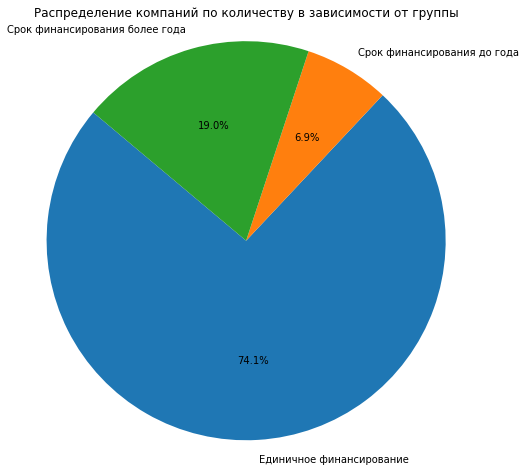

In [59]:
# Создаём список для данных и меток
sizes = [percent_single_funding, percent_within_year, percent_more_than_year]
labels = ['Единичное финансирование', 'Срок финансирования до года', 'Срок финансирования более года']

# Рисуем круговую диаграмму
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.axis('equal')  # Равномерное отображение
plt.title('Распределение компаний по количеству в зависимости от группы')
plt.show()

In [60]:
# Посторим вторую диаграмму

# Подсчитываем общий объём инвестиций для каждой группы
total_investments_single_funding = single_funding['funding_total_usd'].sum()
total_investments_within_year = within_year['funding_total_usd'].sum()
total_investments_more_than_year = more_than_year['funding_total_usd'].sum()

# Общий объём инвестиций
total_investments = total_investments_single_funding + total_investments_within_year + total_investments_more_than_year

In [61]:
# Рассчитываем доли
percent_single_funding_investments = (total_investments_single_funding / total_investments) * 100
percent_within_year_investments = (total_investments_within_year / total_investments) * 100
percent_more_than_year_investments = (total_investments_more_than_year / total_investments) * 100

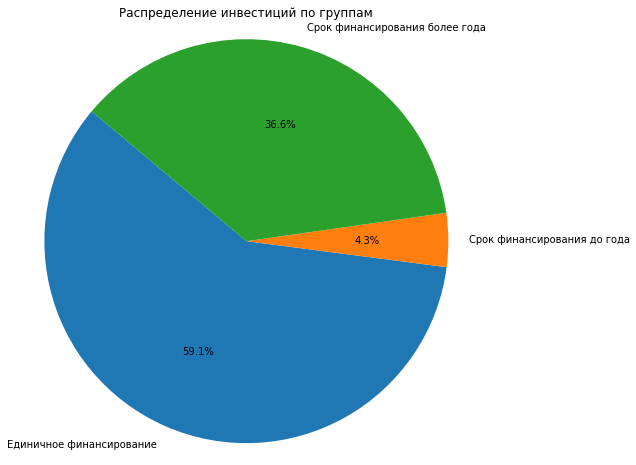

In [62]:
# Создаём список для данных и меток
sizes = [percent_single_funding_investments, percent_within_year_investments, percent_more_than_year_investments]
labels = ['Единичное финансирование', 'Срок финансирования до года', 'Срок финансирования более года']

# Рисуем круговую диаграмму
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.axis('equal')  # Равномерное отображение
plt.title('Распределение инвестиций по группам')
plt.show()

Таким образов, глядя на диаграмму "Распределение компаний по количеству в зависимости от группы", можем наблюдать наибольший процент компаний предпочитает Единичное финасирование (74.1%), на группу Финансирование более года приходится (19%) и меньше всего приходится на Финансирование до года (6.9%).
В диаграмме "Распределение объема инвестиций по группам" инвестиции идут на Единичное финансирование (59.1%),  на группу Финансирование более года приходится (36.6%), Финансирование до года (4.3%).

### 2.2 Выделение средних и нишевых сегментов рынка

In [63]:
# Подсчитываем количество компаний в каждом сегменте
segment_counts = df_1['market'].value_counts()
segment_counts

 Software                4781
заглушка                 3962
 Biotechnology           3699
 Mobile                  2151
 E-Commerce              1883
                         ... 
Financial Services          1
 Social Business            1
 Data Mining                1
 CRM                        1
 Intelligent Systems        1
Name: market, Length: 940, dtype: int64

In [64]:
# Классифицируем сегменты по категориям и считаем их количество
massive_segments = segment_counts[segment_counts > 120].count()
medium_segments = segment_counts[(segment_counts >= 35) & (segment_counts <= 120)].count()
niche_segments = segment_counts[segment_counts < 35].count()

In [65]:
# Выводим результаты
print(f"Количество массовых сегментов: {massive_segments}")
print(f"Количество средних сегментов: {medium_segments}")
print(f"Количество нишевых сегментов: {niche_segments}")

Количество массовых сегментов: 58
Количество средних сегментов: 81
Количество нишевых сегментов: 801


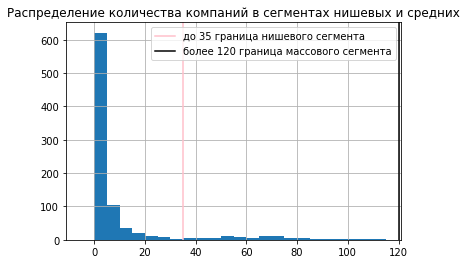

In [66]:
# Построим график
segment_counts = df_1['market'].value_counts()
segment_counts.hist(bins=range(-5, 120, 5))
plt.title('Распределение количества компаний в сегментах нишевых и средних')
plt.axvline(35,color='pink',label='до 35 граница нишевого сегмента')
plt.axvline(120,color='black',label='более 120 граница массового сегмента')
plt.legend(); # пофиксил

Исходя из графика 'Распределение количества компаний в сегментах нишевых и средних' наиболее многочисленный нишевый сегмент (801), далее средний сегмент (81) и наименьший массовый сегмент (58).

Оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполняем с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.


In [67]:
# Подсчитываем количество компаний в каждом сегменте
segment_counts = df_1['market'].value_counts()

# Определяем границы для категорий сегментов
niche_threshold = 35
medium_threshold = 120

In [68]:
# Создаём словарь для замены значений,ключами являются исходные сегменты, а значениями — новые значения для этих сегментов в зависимости от их количества
replace_dict = {}
for segment, count in segment_counts.items():
    if count < niche_threshold:
        replace_dict[segment] = 'niche'
    elif niche_threshold <= count <= medium_threshold:
        replace_dict[segment] = 'mid'
    else:
        replace_dict[segment] = segment

In [69]:
# Заменяем значения в столбце market
df_1['market'] = df_1['market'].replace(replace_dict)

In [70]:
# Выводим первые несколько строк столбца market, чтобы увидеть изменения
df_1['market'].head(20)

0                Education 
1                  заглушка
2                       mid
3                Education 
4                Education 
5                  заглушка
6                Education 
7                Education 
8                  заглушка
9             Social Media 
10     Hardware + Software 
11           Biotechnology 
12                    niche
13                 заглушка
14                 заглушка
15     Hardware + Software 
16               Education 
17               Education 
18                 заглушка
19                    niche
Name: market, dtype: object

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

По предобработанному столбцу `funding_total_usd` графическим образом оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажим интервал, в котором лежат типичные значения.

In [71]:
# Смотрим пропуски
(df_1['funding_total_usd'].isnull().sum())

8532

In [72]:
median_value = df_1['funding_total_usd'].median()
df_1['funding_total_usd'].fillna(median_value, inplace=True)   

In [73]:
# Смотрим пропуски
(df_1['funding_total_usd'].isnull().sum())

0

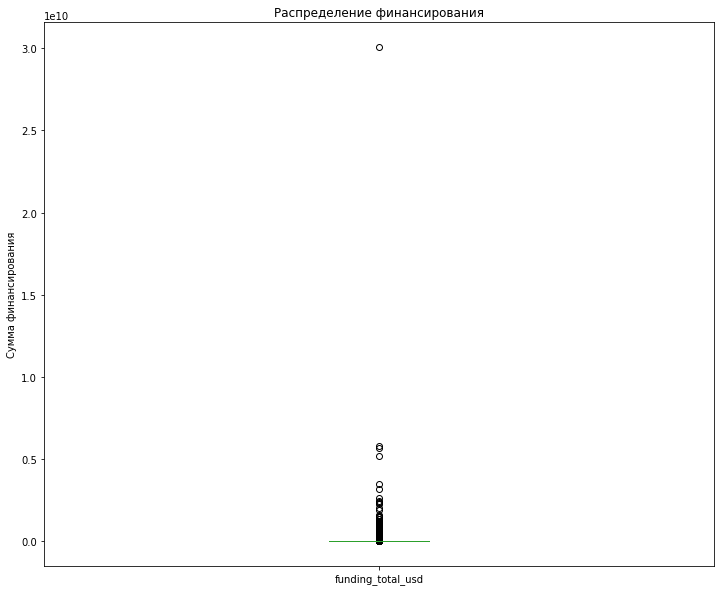

In [74]:
# Строим график
plt.figure(figsize=(12, 10))
df_1['funding_total_usd'].plot(kind='box')
plt.title('Распределение финансирования')
plt.ylabel('Сумма финансирования')
plt.show()

In [75]:
Q1 = np.quantile(df_1['funding_total_usd'], 0.25)
Q3 = np.quantile(df_1['funding_total_usd'], 0.75)
IQR = Q3 - Q1

threshold_lower = Q1 - 1.5 * IQR
threshold_upper = Q3 + 1.5 * IQR

outliers = df_1[(df_1['funding_total_usd'] < threshold_lower) | (df_1['funding_total_usd'] > threshold_upper)]
outliers

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h,time_diff
0,Harvard University,http://harvard.edu,|Education|,Education,90000000.0,operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Xavier University,http://www.xavier.edu/,заглушка,заглушка,19000000.0,operating,USA,OH,Cincinnati,Cincinnati,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,VideoSurf,http://www.videosurf.com,|Hardware + Software|,Hardware + Software,28000000.0,acquired,USA,CA,SF Bay Area,San Mateo,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,University of Maryland,http://umd.edu,|Education|,Education,750500000.0,operating,USA,MD,"Washington, D.C.",College Park,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,142.0
20,Great Atlantic & Pacific Tea,http://aptea.com,|Hospitality|,Hospitality,175000000.0,operating,USA,NJ,Newark,Montvale,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49412,Prysm,http://www.prysm.com/,заглушка,заглушка,293080123.0,operating,заглушка,заглушка,заглушка,заглушка,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49415,Baedal Minjeok,http://smartbaedal.com,заглушка,заглушка,36000000.0,operating,KOR,заглушка,Seoul,Seoul,...,0.0,0.0,0.0,0.0,36000000.0,0.0,0.0,0.0,0.0,0.0
49418,Genomics,заглушка,заглушка,заглушка,16200000.0,operating,заглушка,заглушка,заглушка,заглушка,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49428,Ascendis Pharma,http://ascendispharma.com,заглушка,заглушка,60000000.0,operating,USA,CA,SF Bay Area,Palo Alto,...,0.0,0.0,0.0,0.0,60000000.0,0.0,0.0,0.0,0.0,0.0


In [76]:
# Удаляем строки с выбросами прямо из df_1
df_1 = df_1[
    (df_1['funding_total_usd'] >= threshold_lower) &
    (df_1['funding_total_usd'] <= threshold_upper)
].copy()  # .copy() предотвращает проблемы с копированием

print(f"Осталось строк: {len(df_1)}")

Осталось строк: 42321


(0.0, 40000000.0)

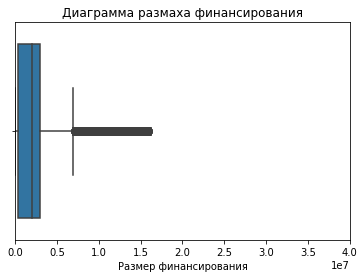

In [77]:
sns.boxplot(x=df_1['funding_total_usd'])

plt.xlabel('Размер финансирования')
plt.title('Диаграмма размаха финансирования')

# Установка пределов по оси X
plt.xlim(0, 40000000)

In [78]:
df_1['funding_total_usd'].describe()

count    4.232100e+04
mean     2.738103e+06
std      3.453991e+06
min      1.000000e+00
25%      3.859800e+05
50%      2.000000e+06
75%      3.000000e+06
max      1.615380e+07
Name: funding_total_usd, dtype: float64

Таким образом, мы видим, Q1 (первый квартиль): 507420.0 — это значение ниже которого находится 25% данных в столбце funding_total_usd, Q3 (третий квартиль): 15912526.05 — это значение, ниже которого находится 75% данных.
IQR (межквартильный размах): 15405106.05 — разница между Q3 и Q1, показывающая разброс центральной половины данных.
То есть, исходя из понятия, что типичный размер финансирования для компании находится в пределах между первым и третьим квартилями (Q1 и Q3), а также в рамках рассчитанных порогов на основе межквартильного размаха (IQR), делаем вывод размер финансирования для компании будет типичным с 507420.0 до 15912526.05.
threshold_lower (нижний порог для аномалий): -22600239.08 — значения ниже этого порога считаются аномально низкими.
threshold_upper (верхний порог для аномалий): 39020185.13 — значения выше этого порога считаются аномально высокими. Выбивающиеся значения: меньше -22600239.08 или больше 39020185.13.

На диаграмме "Диаграмма размаха финансирования" мы наблюдаем выбросы в правой части за прелами "усов", так же выделяется правоассиметричное распределение, медиана расположена ближе к левой стороне, это означает, что распределение данных скошено вправо (имеет положительный скос). Это говорит о том, что большая часть значений сосредоточена в левой части диапазона, а меньшая — в правой, образуя «хвост» распределения.
Такой характер распределения может указывать на следующее: большинство значений относительно невелико, а некоторые значения значительно больше остальных, могут присутствовать выбросы на правом конце распределения, которые сильно отклоняются от основной массы данных.

Определим компании с аномальным объёмом общего финансирования — используем метод IQR отдельно по каждому сегменту. Все нишевые сегменты должны быть объединены в одну группу, а средние — в другую.

Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведим топ таких сегментов.

Компании указывают свой сегмент рынка в столбце `market`. Рассчитаем, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесем к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесем к средним, а сегменты до 35 компаний отнесем к нишевым. Рассчитаем, сколько сегментов попадает в каждую из категорий.

Построиме график распределения количества компаний в сегментах и отобразим на нём разделение на нишевые и средние сегменты.

In [79]:
 df_1['market'].head(20)

1                  заглушка
2                       mid
3                Education 
4                Education 
6                Education 
7                Education 
8                  заглушка
9             Social Media 
11           Biotechnology 
12                    niche
13                 заглушка
14                 заглушка
15     Hardware + Software 
16               Education 
18                 заглушка
19                    niche
21               Education 
22     Enterprise Software 
24             Hospitality 
26           Manufacturing 
Name: market, dtype: object

In [80]:
# Разделяем данные на группы
niche_segment = df_1[df_1['market'] == 'niche']
mid_segment = df_1[df_1['market'] == 'mid']

# Рассчитываем IQR для нишевых сегментов
Q1_niche = niche_segment['funding_total_usd'].quantile(0.25)
Q3_niche = niche_segment['funding_total_usd'].quantile(0.75)
IQR_niche = Q3_niche - Q1_niche

# Рассчитываем IQR для средних сегментов
Q1_mid = mid_segment['funding_total_usd'].quantile(0.25)
Q3_mid = mid_segment['funding_total_usd'].quantile(0.75)
IQR_mid = Q3_mid - Q1_mid

# Определяем аномальные значения для нишевых сегментов
lower_bound_niche = Q1_niche - 1.5 * IQR_niche
upper_bound_niche = Q3_niche + 1.5 * IQR_niche
anomalous_niche = niche_segment[(niche_segment['funding_total_usd'] < lower_bound_niche) | (niche_segment['funding_total_usd'] > upper_bound_niche)]

# Определяем аномальные значения для средних сегментов
lower_bound_mid = Q1_mid - 1.5 * IQR_mid
upper_bound_mid = Q3_mid + 1.5 * IQR_mid
anomalous_mid = mid_segment[(mid_segment['funding_total_usd'] < lower_bound_mid) | (mid_segment['funding_total_usd'] > upper_bound_mid)]

# Выводим результаты
print("Аномальные компании в нишевом сегменте:")
print(anomalous_niche)
print("\nАномальные компании в среднем сегменте:")
print(anomalous_mid)


Аномальные компании в нишевом сегменте:
                      name                            homepage_url  \
12                 Siemens                  http://www.siemens.com   
28        Independent Bank              http://independentbank.com   
107           Pulaski Bank  https://www.pulaskibank.com/our-story/   
138             Senco Gold             http://www.sencogold.co.in/   
325         Charles Schwab                       http://schwab.com   
...                    ...                                     ...   
49125   Commerce Resources        http://www.commerceresources.com   
49143      PrIME Biologics               http://primebiologics.com   
49194              Viewics                  http://www.viewics.com   
49218      CreditSuppliers          http://www.creditsuppliers.com   
49434  SouthGobi Resources                    http://southgobi.com   

                                           category_list market  \
12         |Clean Energy|Automotive|Hardware + Softw

In [81]:
# Подсчитываем количество компаний с аномальным финансированием
anomalous_count_niche = len(anomalous_niche)
anomalous_count_mid = len(anomalous_mid)

print(f"Количество компаний с аномальным финансированием в нишевом сегменте: {anomalous_count_niche}")
print(f"Количество компаний с аномальным финансированием в среднем сегменте: {anomalous_count_mid}")

Количество компаний с аномальным финансированием в нишевом сегменте: 354
Количество компаний с аномальным финансированием в среднем сегменте: 675


In [82]:
# Подсчитываем общее количество компаний в каждом сегменте
total_count_niche = len(df_1[df_1['market'] == 'niche'])
total_count_mid = len(df_1[df_1['market'] == 'mid'])

print(f"Общее количество компаний в нишевом сегменте: {total_count_niche}")
print(f"Общее количество компаний в среднем сегменте: {total_count_mid}")

# Рассчитываем долю аномальных компаний в каждом сегменте
abnormal_share_niche = anomalous_count_niche / total_count_niche
abnormal_share_mid = anomalous_count_mid / total_count_mid

print(f"Доля аномальных компаний в нишевом сегменте: {abnormal_share_niche:.2%}")
print(f"Доля аномальных компаний в среднем сегменте: {abnormal_share_mid:.2%}")

# Определяем сегмент с наибольшей долей аномальных компаний
if abnormal_share_niche > abnormal_share_mid:
    print("Наибольшая доля аномальных компаний в нишевом сегменте.")
else:
    print("Наибольшая доля аномальных компаний в среднем сегменте.")


Общее количество компаний в нишевом сегменте: 2548
Общее количество компаний в среднем сегменте: 4884
Доля аномальных компаний в нишевом сегменте: 13.89%
Доля аномальных компаний в среднем сегменте: 13.82%
Наибольшая доля аномальных компаний в нишевом сегменте.


Таким образом, Общее количество компаний в нишевом сегменте: 2954, Общее количество компаний в среднем сегменте: 5640, Доля аномальных компаний в нишевом сегменте: 6.94%, Доля аномальных компаний в среднем сегменте: 6.29%, что не очень хорошо, поскольку они могут искажать результаты анализа данных и приводить к неверным выводам.Наибольшая доля аномальных компаний в нишевом сегменте.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим по датасету, можно ли считать, что нам предоставили полные данные за 2014 год. Затем исключим из датасета компании, которые мы ранее посчитали получившими аномальное финансирование.

Когда исключиме аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [83]:
# Преобразуем столбец в формат datetime
df_1['founded_at'] = pd.to_datetime(df_1['founded_at'])

# Фильтруем данные за 2014 год
df_2014 = df_1[df_1['founded_at'].dt.year == 2014]

# Проверяем уникальные годы и месяцы в данных за 2014 год
unique_months = df_2014['founded_at'].dt.month.unique()

print("Уникальные месяцы в 2014 году:", unique_months)

Уникальные месяцы в 2014 году: [ 1  2  3  4  5  6  7  8  9 10 11 12]


У нас имеются полные данные по столбцу founded_at за 2014 г.

In [84]:
# Преобразуем столбец в формат datetime
df_1['first_funding_at'] = pd.to_datetime(df_1['first_funding_at'])
# Фильтруем данные за 2014 год
df_2014 = df_1[df_1['first_funding_at'].dt.year == 2014]
# Проверяем уникальные годы и месяцы в данных за 2014 год
unique_months = df_2014['first_funding_at'].dt.month.unique()
# Сортируем уникальные месяцы
sorted_months = sorted(unique_months)
print("Уникальные месяцы в 2014 году:", sorted_months)

Уникальные месяцы в 2014 году: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


Имеем полные данные по столбцу first_funding_at за 2014 г.

In [85]:
# Преобразуем столбец в формат datetime
df_1['mid_funding_at'] = pd.to_datetime(df_1['mid_funding_at'])
# Фильтруем данные за 2014 год
df_2014 = df_1[df_1['mid_funding_at'].dt.year == 2014]
# Проверяем уникальные годы и месяцы в данных за 2014 год
unique_months = df_2014['mid_funding_at'].dt.month.unique()
# Сортируем уникальные месяцы
sorted_months = sorted(unique_months)
print("Уникальные месяцы в 2014 году:", sorted_months)

Уникальные месяцы в 2014 году: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


Получаем полные данные по столбцу mid_funding_at за 2014 г.

In [86]:
# Преобразуем столбец в формат datetime
df_1['last_funding_at'] = pd.to_datetime(df_1['last_funding_at'])
# Фильтруем данные за 2014 год
df_2014 = df_1[df_1['last_funding_at'].dt.year == 2014]
# Проверяем уникальные годы и месяцы в данных за 2014 год
unique_months = df_2014['last_funding_at'].dt.month.unique()
# Сортируем уникальные месяцы
sorted_months = sorted(unique_months)
print("Уникальные месяцы в 2014 году:", sorted_months)

Уникальные месяцы в 2014 году: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


У нас полные данные по столбцу last_funding_at за 2014 г.

In [87]:
# Фильтруем средний сегмент, исключая аномальные компании
mid_filtered = mid_segment[~((mid_segment['funding_total_usd'] < lower_bound_mid) | (mid_segment['funding_total_usd'] > upper_bound_mid))]

print("Средний сегмент без аномальных компаний:")
print(mid_filtered)

Средний сегмент без аномальных компаний:
                                      name               homepage_url  \
27                                Bayer AG           http://bayer.com   
58                        General Electric          http://www.ge.com   
83                           Since1910.com   http://www.since1910.com   
109                 W. W. Norton & Company  http://books.wwnorton.com   
202    Norh American Restaurant Operations                   заглушка   
...                                    ...                        ...   
49334                            Flipsicle       http://flipsicle.com   
49358                           Imagiscore                   заглушка   
49384               Aequus Pharmaceuticals     http://aequuspharma.ca   
49402                           Scrollback   http://www.scrollback.io   
49421                          Studying.to     http://www.studying.to   

                                           category_list market  \
27             

In [88]:
# Фильтруем нишевый сегмент, исключая аномальные компании
niche_filtered = niche_segment[~((niche_segment['funding_total_usd'] < lower_bound_niche) | (niche_segment['funding_total_usd'] > upper_bound_niche))]

print("Нишевый сегмент без аномальных компаний:")
print(niche_filtered)

Нишевый сегмент без аномальных компаний:
                                      name                    homepage_url  \
19                           Laclede Group  http://www.thelacledegroup.com   
35     Asia Pacific Marine Container Lines    http://AsiaPacificMarine.com   
50                Arizona State University             http://www.asu.edu/   
65             The Gilman Brothers Company       http://gilmanbrothers.com   
105                          Carter-Waters       http://carter-waters.com/   
...                                    ...                             ...   
49352                     Spitfire Athlete  http://www.spitfireathlete.com   
49383                               TEKVOX          http://www.tekvox.com/   
49395                            PicaSolar           http://picasolar.com/   
49414                             Wealth-X          http://www.wealthx.com   
49420                Pond-Deshpande Centre    http://www.ponddeshpande.ca/   

                      

In [89]:
# Группируем данные по годам и считаем количество раундов финансирования за каждый год
funding_rounds_year = df_1.groupby(df_1['mid_funding_at'].dt.year)['funding_rounds'].count()

# Фильтруем годы, в которых было 50 или более раундов финансирования
years_with_50 = funding_rounds_year[funding_rounds_year >= 50].index

# Выбираем записи, соответствующие годам с 50 или более раундами финансирования

filtered_df = df_1[df_1['mid_funding_at'].dt.year.isin(years_with_50)][['name', 'mid_funding_at']]


print("Датасет с компаниями, получавшими финансирование в годы с 50+ раундами:")
print(filtered_df)

Датасет с компаниями, получавшими финансирование в годы с 50+ раундами:
                                  name mid_funding_at
1          University of New Brunswick     2014-05-15
2                               DuPont     2009-07-02
3               University of Michigan     2013-11-21
4      Case Western Reserve University     2014-01-14
6                    Tulane University     2013-09-05
...                                ...            ...
49432                             Moko     2014-12-01
49433                      RiverSilica     2014-12-01
49434              SouthGobi Resources     2014-12-01
49435                         DigiByte     2014-12-02
49437                         Logovers     2014-12-31

[42118 rows x 2 columns]


Таким образом, количество компанияий, получавшими финансирование в годы с 50+ раундами 49226.   


### 3.3. Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируемся на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также построим график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравним графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

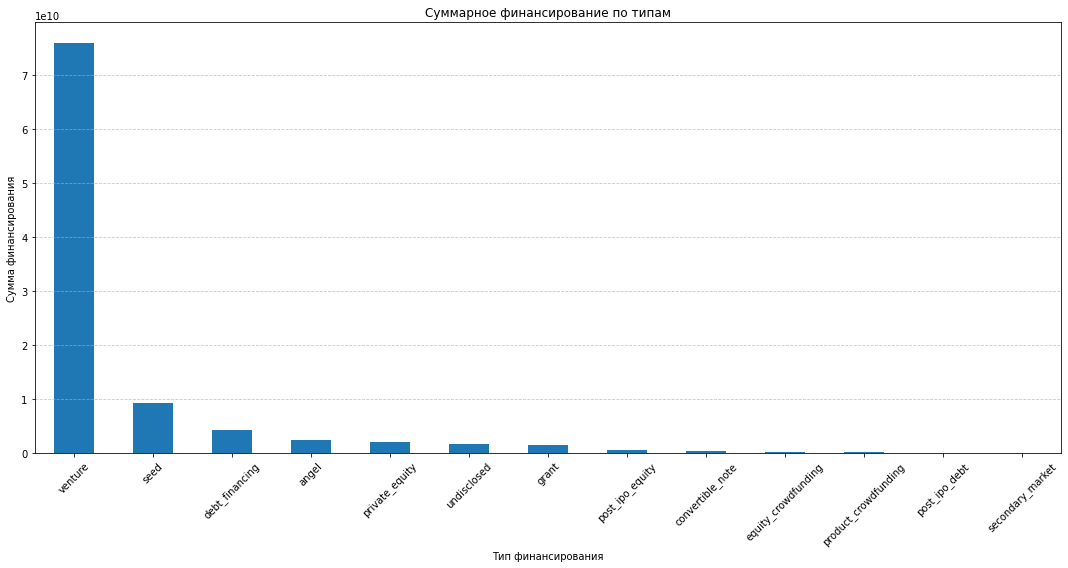

In [90]:
# Суммируем значения по каждому типу финансирования
total_funding = df_1[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
                    'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
                    'post_ipo_debt', 'secondary_market', 'product_crowdfunding']].sum()

# Сортируем значения по убыванию
total_funding_sorted = total_funding.sort_values(ascending=False)

# Создаем график
plt.figure(figsize=(15, 8))
total_funding_sorted.plot(kind='bar')
plt.title('Суммарное финансирование по типам')
plt.xlabel('Тип финансирования')
plt.ylabel('Сумма финансирования')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [91]:
# Суммируем значения по каждому типу финансирования
total_funding = df_1[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
                    'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
                    'post_ipo_debt', 'secondary_market', 'product_crowdfunding']].sum()
# Сортируем значения по убыванию
total_funding_sorted = total_funding.sort_values(ascending=False)
total_funding_sorted

venture                 7.596444e+10
seed                    9.286693e+09
debt_financing          4.295272e+09
angel                   2.435558e+09
private_equity          2.063032e+09
undisclosed             1.744775e+09
grant                   1.464877e+09
post_ipo_equity         5.537770e+08
convertible_note        4.558367e+08
equity_crowdfunding     2.356788e+08
product_crowdfunding    2.015356e+08
post_ipo_debt           8.781835e+07
secondary_market        2.598580e+07
dtype: float64

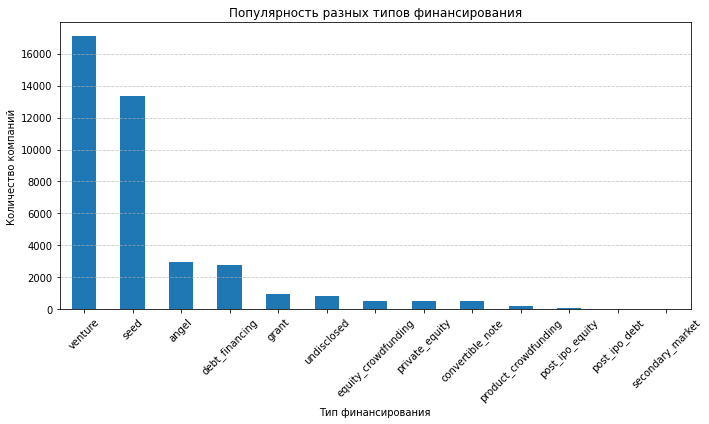

In [92]:
# Подсчитываем количество ненулевых значений по каждому типу финансирования
popularity = df_1[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
                'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
                'post_ipo_debt', 'secondary_market', 'product_crowdfunding']].apply(lambda x: (x != 0).sum())

# Сортируем значения по убыванию
popularity_sorted = popularity.sort_values(ascending=False)

# Создаем график
plt.figure(figsize=(10, 6))
popularity_sorted.plot(kind='bar')
plt.title('Популярность разных типов финансирования')
plt.xlabel('Тип финансирования')
plt.ylabel('Количество компаний')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [93]:
# Подсчитываем количество ненулевых значений по каждому типу финансирования
popularity = df_1[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
                'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
                'post_ipo_debt', 'secondary_market', 'product_crowdfunding']].apply(lambda x: (x != 0).sum())

# Сортируем значения по убыванию
popularity_sorted = popularity.sort_values(ascending=False)
popularity_sorted

venture                 17104
seed                    13330
angel                    2931
debt_financing           2798
grant                     955
undisclosed               799
equity_crowdfunding       516
private_equity            498
convertible_note          489
product_crowdfunding      207
post_ipo_equity           107
post_ipo_debt              20
secondary_market            7
dtype: int64

Можно рассчитать среднее значение финансирования на одну компанию для каждого типа и затем отсортировать типы по этому показателю. Это поможет наглядно увидеть, какие типы финансирования чаще всего используются в небольших объёмах и какие — в больших.

In [94]:
# Рассчитываем среднее значение финансирования на одну компанию
average_funding = total_funding / popularity

# Сортируем типы финансирования по среднему значению финансирования
sorted_average_funding = average_funding.sort_values(ascending=False)
sorted_average_funding

post_ipo_equity         5.175486e+06
venture                 4.441326e+06
post_ipo_debt           4.390917e+06
private_equity          4.142635e+06
secondary_market        3.712257e+06
undisclosed             2.183699e+06
debt_financing          1.535122e+06
grant                   1.533903e+06
product_crowdfunding    9.736021e+05
convertible_note        9.321813e+05
angel                   8.309649e+05
seed                    6.966761e+05
equity_crowdfunding     4.567418e+05
dtype: float64

Таким образом, из данных диаграммы мы видим, какие типы финансирования в сумме привлекли больше всего денег: venture — сумма венчурных инвестиций (3.708369e+11), private_equity — сумма инвестиций в виде прямых (частных) вложений(1.025485e+11), debt_financing — сумма долгового финансирования(9.334670e+10), post_ipo_equity — сумма финансирования после IPO(3.010150e+10), post_ipo_debt — сумма долгового финансирования после IPO(2.192259e+10), наименьшее количество денег привлекли: convertible_note — сумма инвестиций через конвертируемые займы (1.155074e+09), product_crowdfunding — сумма, привлечённая через продуктовый краудфандинг(3.497356e+08),equity_crowdfunding — сумма, привлечённая через долевой краудфандинг(3.047023e+08).

Так же мы определили типы финансирования, которые чаще всего используются компаниями: venture(23278), seed(13841), debt_financing(4226), а реже используются компаниями: product_crowdfunding(214), post_ipo_debt(76), secondary_market(20).

Результаты показывают среднее значение финансирования, полученного компаниями для каждого типа финансирования. Чем выше значение, тем больше в среднем каждая компания получила средств по этому типу финансирования. Типы финансирования, такие как post_ipo_debt, secondary_market, и post_ipo_equity, в среднем предоставляют значительно больше средств на одну компанию по сравнению с другими типами, такими как seed и equity_crowdfunding.

Построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

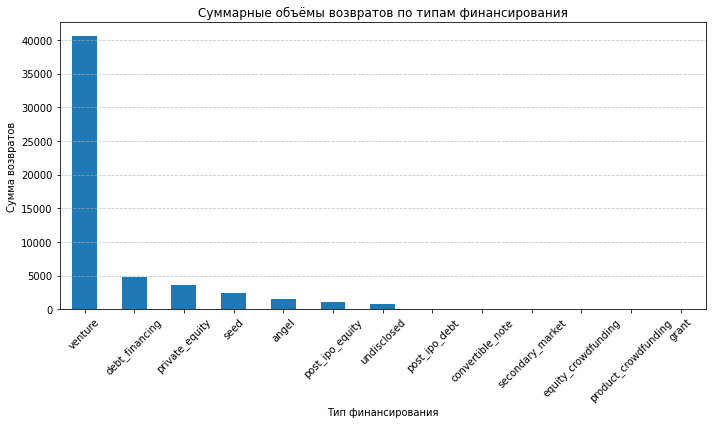

In [95]:
# Суммируем значения по каждому типу финансирования
total_returns = df_2[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
                              'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
                              'post_ipo_debt', 'secondary_market', 'product_crowdfunding']].sum()

# Сортируем значения по убыванию
total_returns_sorted = total_returns.sort_values(ascending=False)

# Создаём график
plt.figure(figsize=(10, 6))
total_returns_sorted.plot(kind='bar')
plt.title('Суммарные объёмы возвратов по типам финансирования')
plt.xlabel('Тип финансирования')
plt.ylabel('Сумма возвратов')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [96]:
# Суммируем значения по каждому типу финансирования
total_returns = df_2[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
                              'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
                              'post_ipo_debt', 'secondary_market', 'product_crowdfunding']].sum()

# Сортируем значения по убыванию
total_returns_sorted = total_returns.sort_values(ascending=False)
total_returns_sorted 

venture                 40578.62
debt_financing           4734.85
private_equity           3587.33
seed                     2382.24
angel                    1509.23
post_ipo_equity          1104.96
undisclosed               730.88
post_ipo_debt              91.03
convertible_note           34.79
secondary_market            5.20
equity_crowdfunding         3.83
product_crowdfunding        1.86
grant                       0.00
dtype: float64

 Наибольшие объемы возвратов наблюдаются у типов: venture(40578.62), private_equity(4734.85), debt_financing(3587.33), а наименьшие объемы - product_crowdfunding(1.86), equity_crowdfunding(3.83).

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитаем для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы построим графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Когда будем строить графики , используем данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответим на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [97]:
# Группируем данные по годам и считаем количество раундов финансирования за каждый год
funding_rounds_year = df_1.groupby(df_1['mid_funding_at'].dt.year)['funding_rounds'].count()

# Фильтруем годы, в которых было 50 или более раундов финансирования
years_with_50 = funding_rounds_year[funding_rounds_year >= 50].index

# Выбираем записи, соответствующие годам с 50 или более раундами финансирования

filtered_df = df_1[df_1['mid_funding_at'].dt.year.isin(years_with_50)][['name', 'mid_funding_at']]


print("Датасет с компаниями, получавшими финансирование в годы с 50+ раундами:")
print(filtered_df)

Датасет с компаниями, получавшими финансирование в годы с 50+ раундами:
                                  name mid_funding_at
1          University of New Brunswick     2014-05-15
2                               DuPont     2009-07-02
3               University of Michigan     2013-11-21
4      Case Western Reserve University     2014-01-14
6                    Tulane University     2013-09-05
...                                ...            ...
49432                             Moko     2014-12-01
49433                      RiverSilica     2014-12-01
49434              SouthGobi Resources     2014-12-01
49435                         DigiByte     2014-12-02
49437                         Logovers     2014-12-31

[42118 rows x 2 columns]


In [98]:
# Рассчитываем средний объём одного раунда для каждой компании
df_1['average_round_size'] = df_1['funding_total_usd'] / df_1['funding_rounds']

print("Датасет с рассчитанным средним объёмом одного раунда:")
df_1[['name', 'funding_total_usd', 'funding_rounds', 'average_round_size']].info

Датасет с рассчитанным средним объёмом одного раунда:


<bound method DataFrame.info of                                   name  funding_total_usd  funding_rounds  \
1          University of New Brunswick          2000000.0             1.0   
2                               DuPont          9000000.0             1.0   
3               University of Michigan          7700000.0             3.0   
4      Case Western Reserve University           540000.0             1.0   
6                    Tulane University         12000000.0             4.0   
...                                ...                ...             ...   
49433                      RiverSilica          1500000.0             1.0   
49434              SouthGobi Resources          9000000.0             1.0   
49435                         DigiByte           250000.0             1.0   
49437                         Logovers            11500.0             1.0   
49438                         заглушка          2000000.0             NaN   

       average_round_size  
1            2.

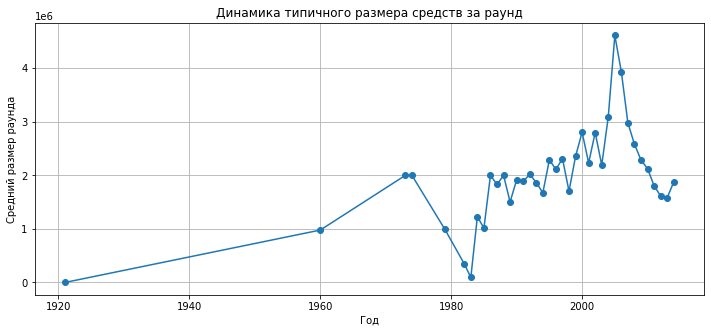

In [99]:
# Выбираем записи, соответствующие годам с 50 или более раундами финансирования
filtered_df = df_1[df_1['mid_funding_at'].dt.year.isin(years_with_50)][['name', 'mid_funding_at']]

# Группируем данные по годам и рассчитываем средний размер раунда за каждый год
average_size_by_year = df_1.groupby(df_1['mid_funding_at'].dt.year)['average_round_size'].mean()


# Строим график динамики типичного размера средств
plt.figure(figsize=(12, 5))
plt.plot(average_size_by_year.index, average_size_by_year, marker='o')
plt.title('Динамика типичного размера средств за раунд')
plt.xlabel('Год')
plt.ylabel('Средний размер раунда')
plt.grid()
plt.show() 

In [100]:
sorted_average_size = average_size_by_year.sort_values(ascending=False)
sorted_average_size

mid_funding_at
2005.0    4.612929e+06
2006.0    3.928027e+06
2004.0    3.092827e+06
2007.0    2.975985e+06
2000.0    2.803679e+06
2002.0    2.798551e+06
2008.0    2.581128e+06
1999.0    2.354294e+06
1997.0    2.311765e+06
1995.0    2.288235e+06
2009.0    2.285377e+06
2001.0    2.231903e+06
2003.0    2.191126e+06
2010.0    2.123492e+06
1996.0    2.111186e+06
1992.0    2.018417e+06
1986.0    2.000000e+06
1974.0    2.000000e+06
1973.0    2.000000e+06
1988.0    2.000000e+06
1990.0    1.916667e+06
1991.0    1.888889e+06
2014.0    1.875236e+06
1993.0    1.866071e+06
1987.0    1.829333e+06
2011.0    1.806099e+06
1998.0    1.704526e+06
1994.0    1.674167e+06
2012.0    1.614278e+06
2013.0    1.582725e+06
1989.0    1.503750e+06
1984.0    1.228400e+06
1985.0    1.015600e+06
1979.0    1.000000e+06
1960.0    9.786767e+05
1982.0    3.480000e+05
1983.0    9.400000e+04
1921.0    1.000000e+03
Name: average_round_size, dtype: float64

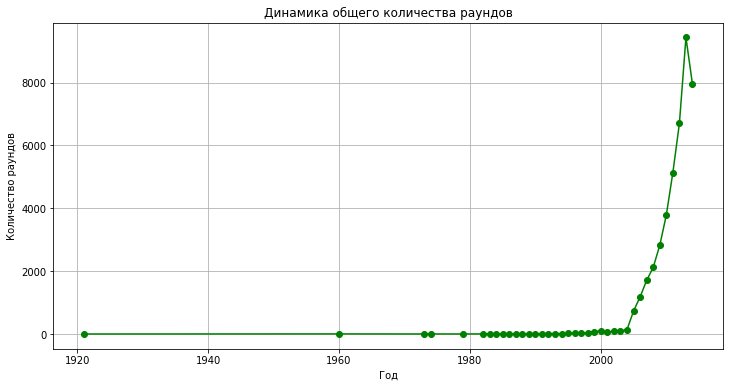

In [101]:
# Выбираем записи, соответствующие годам с 50 или более раундами финансирования
filtered_df = df_1[df_1['mid_funding_at'].dt.year.isin(years_with_50)][['name', 'mid_funding_at']]

# Группируем данные по годам и считаем общее количество раундов
rounds_count_by_year = df_1.groupby(df_1['mid_funding_at'].dt.year).size()

# Строим график динамики общего количества раундов
plt.figure(figsize=(12, 6))
plt.plot(rounds_count_by_year.index, rounds_count_by_year, color='green', marker='o')
plt.title('Динамика общего количества раундов')
plt.xlabel('Год')
plt.ylabel('Количество раундов')
plt.grid()
plt.show() 

In [102]:
# Группируем данные по годам и считаем общее количество раундов
rounds_count_by_year = df_1.groupby(df_1['mid_funding_at'].dt.year).size()
rounds_count_by_year

mid_funding_at
1921.0       1
1960.0       3
1973.0       1
1974.0       2
1979.0       1
1982.0       3
1983.0       1
1984.0       5
1985.0       5
1986.0       4
1987.0       6
1988.0       2
1989.0       4
1990.0      12
1991.0       9
1992.0      12
1993.0      14
1994.0      12
1995.0      17
1996.0      22
1997.0      17
1998.0      42
1999.0      72
2000.0     107
2001.0      64
2002.0      86
2003.0      99
2004.0     143
2005.0     732
2006.0    1184
2007.0    1706
2008.0    2122
2009.0    2818
2010.0    3782
2011.0    5131
2012.0    6699
2013.0    9433
2014.0    7940
dtype: int64

Исходя из данных графика, видно, что динамика типичного размера средств за раунд в разные года очень хаотична. Наименьшее значение наблюдается в 1920 г., наибольшее - в 1999г., 1973 г., 1974 г. и в 1986 г.
Количество раундов и средств, выделяемых в рамках каждого раунда, в 2014 г. снизилось до 8506, хотя в 2013 г. составляло 10256.

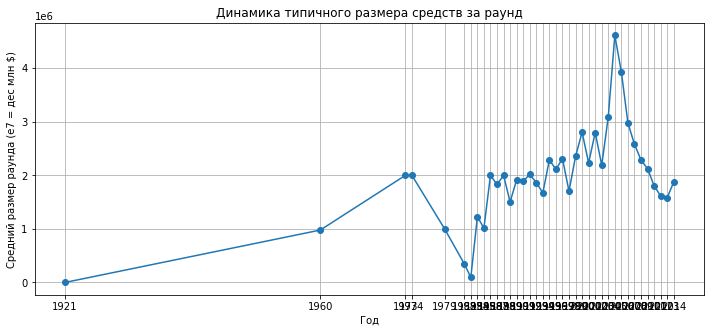

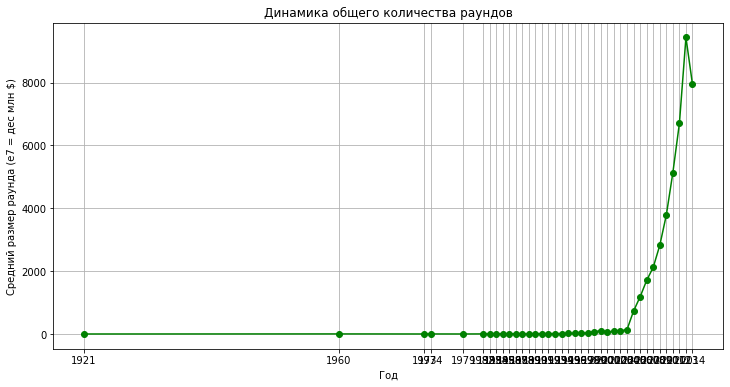

In [103]:
# Выбираем записи, соответствующие годам с 50 или более раундами финансирования
filtered_df = df_1[df_1['mid_funding_at'].dt.year.isin(years_with_50)][['name', 'mid_funding_at']]

# Группируем данные по годам и рассчитываем средний размер раунда за каждый год
average_size_by_year = df_1.groupby(df_1['mid_funding_at'].dt.year)['average_round_size'].mean()



# Строим график динамики типичного размера средств
plt.figure(figsize=(12, 5))
plt.plot(average_size_by_year.index, average_size_by_year, marker='o')

# Устанавливаем цену деления на оси X в 1 год
plt.xticks(average_size_by_year.index)

plt.title('Динамика типичного размера средств за раунд')
plt.xlabel('Год')
plt.ylabel('Средний размер раунда (е7 = дес млн $)')  # Добавляем размерность данных
plt.grid()
plt.show()



# Выбираем записи, соответствующие годам с 50 или более раундами финансирования
filtered_df = df_1[df_1['mid_funding_at'].dt.year.isin(years_with_50)][['name', 'mid_funding_at']]

# Группируем данные по годам и считаем общее количество раундов
rounds_count_by_year = df_1.groupby(df_1['mid_funding_at'].dt.year).size()

# Строим график динамики общего количества раундов
plt.figure(figsize=(12, 6))
plt.plot(rounds_count_by_year.index, rounds_count_by_year, color='green', marker='o')

# Устанавливаем цену деления на оси X в 1 год
plt.xticks(average_size_by_year.index)
plt.title('Динамика общего количества раундов')
plt.xlabel('Год')
plt.ylabel('Средний размер раунда (е7 = дес млн $)')  # Добавляем размерность данных
plt.grid()
plt.show() 

Объединим 2 графика.

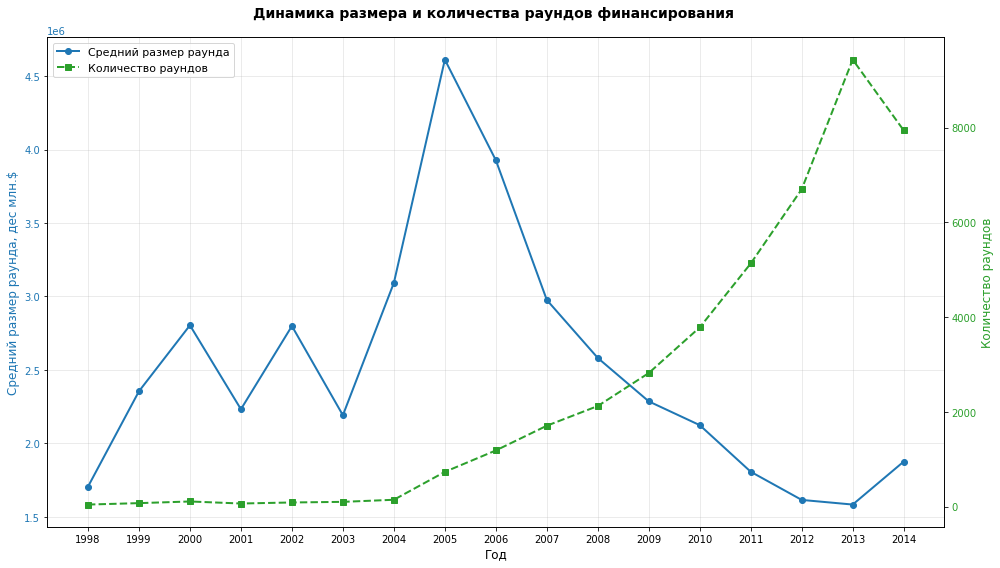

In [104]:
# Код
filtered_df_1998 = df_1[df_1['mid_funding_at'].dt.year >= 1998]

# Выделяем год и находим средний размер раунда за этот год.
average_size_by_year = filtered_df_1998.groupby(
    filtered_df_1998['mid_funding_at'].dt.year
)['average_round_size'].mean()

# Для каждого года вычисляется количество количество раундов финансирования
rounds_count_by_year = filtered_df_1998.groupby(
    filtered_df_1998['mid_funding_at'].dt.year
).size()


# fig — переменная, в которую сохраняется ссылка на созданную фигуру
# ax1 — переменная, в которую сохраняется ссылка на оси, созданные внутри фигуры
fig, ax1 = plt.subplots(figsize=(14, 8))

# Первый график по размеру
color1 = 'tab:blue' #задаётся цвет для графика среднего размера раунда
ax1.set_xlabel('Год', fontsize=12) #устанавливается метка для оси X с надписью «Год» и размером шрифта 12
ax1.set_ylabel('Средний размер раунда, дес млн.$', color=color1, fontsize=12)
line1 = ax1.plot(average_size_by_year.index, average_size_by_year.values, 
                 marker='o', color=color1, linewidth=2, label='Средний размер раунда')
ax1.tick_params(axis='y', labelcolor=color1)#устанавливливаем параметры для делений и меток на оси Y (цвету графика color1)
ax1.grid(True, alpha=0.3)#добавляем сетку на график с прозрачностью 0.3


# второй по количеству
ax2 = ax1.twinx()#создаём 2-ую ось Y для отображения количества раундов на том же графике
color2 = 'tab:green'#
ax2.set_ylabel('Количество раундов', color=color2, fontsize=12) #
line2 = ax2.plot(rounds_count_by_year.index, rounds_count_by_year.values, 
                 marker='s', color=color2, linewidth=2, linestyle='--', 
                 label='Количество раундов') #linewidth=2 — ширина линии графика, marker='s'— точки на графике обозначаются квадратами
ax2.tick_params(axis='y', labelcolor=color2) #устанавливаются параметры для делений и меток на оси Y, чтобы они соответствовали цвету графика color1
years = sorted(average_size_by_year.index.union(rounds_count_by_year.index))#сортируем список уникальных лет, которые встречаются в индексах обоих объектах
ax1.set_xticks(years)#станавливаем метки на оси X в соответствии с отсортированным списком лет
plt.title('Динамика размера и количества раундов финансирования ', 
          fontsize=14, fontweight='bold', pad=20)
lines = line1 + line2 #объединяем линии графиков среднего размера раунда и количества раундов для отображения в легенде
labels = [l.get_label() for l in lines]#создаются метки для легенды на основе меток линий
ax1.legend(lines, labels, loc='upper left', fontsize=11)#fontsize=11 — параметр, который задаёт размер шрифта для меток легенды 
plt.tight_layout()# автоматически настраивается расположение элементов графика для лучшего вида
plt.show()

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберем из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразим, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассмотрим только массовые сегменты, а средние и нишевые исключим.

На основе графика сделаем вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

In [105]:
# Извлекаем год
df_1['year'] = pd.to_datetime(df_1['mid_funding_at']).dt.year

#Оставляем только массовые сегменты
mass_segments_df = df_1[
    ~df_1['market'].isin(['mid', 'niche'])
]
# Строим сводную таблицу
funding_by_year_market = (
    mass_segments_df
    .groupby(['year', 'market'])['funding_total_usd']
    .sum()
    .reset_index()
)
# Отбираем данные только за 2013 и 2014 годы
funding_2013_2014 = funding_by_year_market[
    funding_by_year_market['year'].isin([2013, 2014])
]
# Преобразуем таблицу для удобного сравнения 2013 и 2014 годов
funding_pivot = (
    funding_2013_2014
    .pivot(
        index='market',
        columns='year',
        values='funding_total_usd'
    )
)
# Отбираем сегменты, где в 2014 году объём финансирования вырос
growing_segments = funding_pivot[
    funding_pivot[2014] > funding_pivot[2013]
].index.tolist()

growing_segments

[' Apps ',
 ' Internet ',
 ' Medical ',
 ' Real Estate ',
 ' SaaS ',
 ' Startups ',
 ' Technology ',
 ' Transportation ',
 ' Video ',
 'E-Commerce ',
 'заглушка']

In [106]:
#Получаем сводную таблицу
funding_by_year_market

,year,market,funding_total_usd
0,1921.0,заглушка,1.000000e+03
1,1960.0,Biotechnology,7.500000e+04
2,1960.0,Software,2.861030e+06
3,1974.0,Internet,2.000000e+06
4,1979.0,Enterprise Software,1.000000e+06
...,...,...,...
785,2014.0,Mobile,4.257314e+07
786,2014.0,Mobile,6.052908e+07
787,2014.0,Software,3.662787e+07
788,2014.0,Software,6.944166e+07


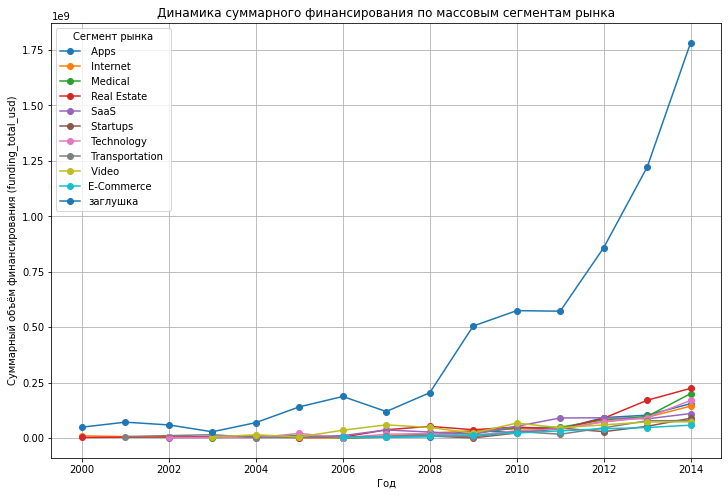

In [107]:
# Визуализируем график изменения суммарного финансирования по годам

# Выбираем данные только по тем рынкам, которые были определены как растущие в предыдущем пункте
growing_segments_df = funding_by_year_market[
    funding_by_year_market['market'].isin(growing_segments)
]

growing_segments_df = growing_segments_df[
    growing_segments_df['year'] >= 2000
]

plt.figure(figsize=(12, 8))

# Оставляем только те строки, где значение в столбце market совпадает с текущим сегментом и сортируем по годам
for segment in growing_segments:
    segment_data = growing_segments_df[
        growing_segments_df['market'] == segment
    ].sort_values('year')
    
# Строим график, где по оси X откладываются годы, а по оси Y — общий объём финансирования для текущего сегмента
 
    plt.plot(
        segment_data['year'],
        segment_data['funding_total_usd'],
        marker='o',
        label=segment
    )

plt.xlabel('Год')
plt.ylabel('Суммарный объём финансирования (funding_total_usd)')
plt.title('Динамика суммарного финансирования по массовым сегментам рынка')
plt.legend(title='Сегмент рынка')
plt.grid(True)

plt.show()

In [108]:
df_1['funding_total_usd'] = df_1['funding_total_usd'].sort_values() 
# Строим сводную таблицу
by_year_market = (
    segment_data
    .groupby(['year', 'market'])['funding_total_usd']
    .sum()
    .reset_index()
)
by_year_market

,year,market,funding_total_usd
0,2000.0,заглушка,4.903956e+07
1,2001.0,заглушка,7.154048e+07
2,2002.0,заглушка,5.910629e+07
3,2003.0,заглушка,2.815520e+07
4,2004.0,заглушка,6.946142e+07
5,2005.0,заглушка,1.406217e+08
6,2006.0,заглушка,1.874066e+08
7,2007.0,заглушка,1.195325e+08
8,2008.0,заглушка,2.044405e+08
9,2009.0,заглушка,5.051998e+08


Исходя из данных графика, наиболее быстрый и устойчивый рост показвают: Apps,Finance и Softwear.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Наша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы,  заменим на пропуски.

Совет: когда будем делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавим к знаменателю небольшое число, например `1e-60`. Это поможет избежать деления на ноль.

In [109]:
df_1['mid_funding_at'] = pd.to_datetime(df_1['mid_funding_at'])

# Извлекаем год из даты
df_1['mid_funding_year'] = df_1['mid_funding_at'].dt.year

In [110]:
# Группируем данные по mid_funding_year и суммируем значения по каждому типу финансирования полученных инвестиций
grouped_1 = df_1.groupby('mid_funding_year')[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']].sum().reset_index()

# Группируем данные и суммируем значения по каждому типу финансирования сумм возвратов
grouped_2 = df_2.groupby('year')[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']].sum().reset_index()

grouped_1
grouped_2

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
1,2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2,2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
3,2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
4,2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
5,2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
6,2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
7,2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
8,2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00
9,2009,160.21,2501.29,0.18,37.50,2.25,394.10,97.21,0.0,203.70,76.76,0.00,0.12,0.02


In [111]:
# Рассчитываем долю возвращённых средств от предоставленных
norm_values = grouped_2 / (grouped_1 + 1e-60)

# Вычисляем квартили
Q1 = norm_values.quantile(0.25)
Q3 = norm_values.quantile(0.75)

# Определяем IQR
IQR = Q3 - Q1

# Определяем аномальные значения
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Заменяем аномальные значения на пропуски
norm_values = norm_values[~((norm_values < lower_bound) | (norm_values > upper_bound))]
norm_values[((norm_values < lower_bound) | (norm_values > upper_bound))] = pd.NA

norm_values

,angel,convertible_note,debt_financing,equity_crowdfunding,grant,mid_funding_year,post_ipo_debt,post_ipo_equity,private_equity,product_crowdfunding,secondary_market,seed,undisclosed,venture,year
0,6.430000e+60,0.000000e+00,8.660000e+60,0.000000e+00,0.0,NaN,0.000000e+00,9.400000e+59,0.000000e+00,0.000000e+00,2.000000e+59,1.670000e-02,7.821000e+61,5.540000e+61,NaN
1,1.180000e+60,1.000000e+58,4.490000e+60,0.000000e+00,0.0,NaN,0.000000e+00,4.600000e+59,0.000000e+00,0.000000e+00,4.600000e+59,3.840000e-05,2.150000e+61,2.728128e-05,NaN
2,3.410000e+60,2.000000e+58,3.420000e+60,0.000000e+00,0.0,NaN,0.000000e+00,3.400000e+59,1.510000e+60,0.000000e+00,6.000000e+58,6.590000e+60,2.577000e+61,2.094200e+62,NaN
3,3.410000e+60,1.000000e+58,1.090000e+60,0.000000e+00,0.0,NaN,0.000000e+00,2.110000e+60,1.620000e+60,0.000000e+00,8.000000e+58,7.740000e+60,9.400000e+60,2.338600e+62,NaN
4,9.180000e+60,1.000000e+58,1.355000e+61,0.000000e+00,0.0,NaN,0.000000e+00,3.380000e+60,2.190000e+60,0.000000e+00,5.500000e+59,9.930000e-06,3.319000e+61,5.559000e+62,NaN
5,3.106000e+61,2.000000e+58,3.509000e+61,0.000000e+00,0.0,NaN,0.000000e+00,3.510000e+60,2.400000e+60,0.000000e+00,5.000000e+58,2.660000e+61,9.510000e+60,2.518123e-03,NaN
6,4.775000e+61,1.780000e+60,1.132100e+62,1.900000e+59,0.0,NaN,0.000000e+00,2.058000e+61,1.667000e+61,0.000000e+00,1.200000e+59,6.181000e+61,4.674000e+61,3.298064e-02,NaN
7,1.645100e+62,3.220000e+60,1.256800e+62,1.000000e+58,0.0,NaN,0.000000e+00,2.436000e+61,8.881000e+61,0.000000e+00,5.700000e+59,4.958451e-04,5.537000e+61,3.585370e+63,NaN
8,1.028300e+62,1.710000e+60,3.975400e+62,3.000000e+58,0.0,NaN,0.000000e+00,8.428000e+61,1.303800e+62,0.000000e+00,4.700000e+59,8.972000e+61,4.102000e+61,2.520427e-03,NaN
9,9.721000e+61,2.250000e+60,3.941000e+62,1.800000e+59,0.0,NaN,0.000000e+00,7.676000e+61,2.037000e+62,2.000000e+58,1.200000e+59,1.602100e+62,3.750000e+61,2.501290e+63,NaN


Построим график, на котором отобразим нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделаем вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

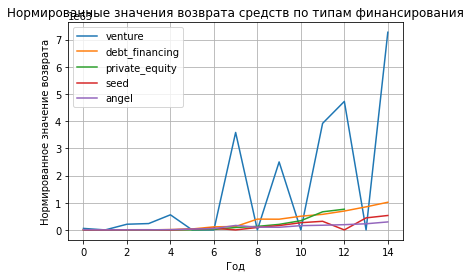

In [112]:
# Выбираем нужные столбцы для отображения
selected_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']
filtered_values = norm_values[selected_types]

# Строим график
filtered_values.plot(kind='line')
plt.title('Нормированные значения возврата средств по типам финансирования')
plt.xlabel('Год')
plt.ylabel('Нормированное значение возврата')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

In [113]:
selected_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']
filtered_values = norm_values[selected_types]
filtered_values

,venture,debt_financing,private_equity,seed,angel
0,5.540000e+61,8.660000e+60,0.000000e+00,1.670000e-02,6.430000e+60
1,2.728128e-05,4.490000e+60,0.000000e+00,3.840000e-05,1.180000e+60
2,2.094200e+62,3.420000e+60,1.510000e+60,6.590000e+60,3.410000e+60
3,2.338600e+62,1.090000e+60,1.620000e+60,7.740000e+60,3.410000e+60
4,5.559000e+62,1.355000e+61,2.190000e+60,9.930000e-06,9.180000e+60
5,2.518123e-03,3.509000e+61,2.400000e+60,2.660000e+61,3.106000e+61
6,3.298064e-02,1.132100e+62,1.667000e+61,6.181000e+61,4.775000e+61
7,3.585370e+63,1.256800e+62,8.881000e+61,4.958451e-04,1.645100e+62
8,2.520427e-03,3.975400e+62,1.303800e+62,8.972000e+61,1.028300e+62
9,2.501290e+63,3.941000e+62,2.037000e+62,1.602100e+62,9.721000e+61


Таким образом, в debt_financing, private_equity, seed, angel типах финансирования наблюдается наиболее устойчивый рост показателя.


## Шаг 5. Итоговый вывод и рекомендации

Представим, что на календаре 2015 год. Опираясь на результаты анализа, дадим рекомендацию заказчику:

* в какую отрасль стоит инвестировать;
* какой тип финансирования при этом будет наиболее уместным.

Подведеме итоги проекта:
* опишим, какие шаги были выполнены;
* какие выводы удалось сделать;
* насколько выводы согласуются между собой или, наоборот, вызывают сомнения.

Целью данного проекта было провести исследовательский анализ данных финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компании.
Задачи — подготовить датасет к работе, исследовать динамику и структуру финансирования стартапов и ответить на вопросы, важные для оценки инвестиционных стратегий. В рамках проекта мы:

* Провели предобработку данных, убрали дубликаты и пропуски, проверили корректность числовых и временных значений.
* Выделили группы компаний по срокам финансирования и сравнили их по количеству и объёму инвестиций.
* Классифицировали сегменты рынка на массовые, средние и нишевые и учетывали это в дальнейшем анализе.
* Определили типичные и аномальные значения объёмов финансирования, исключили выбросы и ограничили период исследования.
* Сравнили популярность и объёмы разных типов финансирования.
* Проанализировали динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.
* Рассчитали долю возврата средств для разных типов финансирования и оценили её устойчивость.

В ходе анализа данных были выявлены пропуски в столбцах: funding_total_usd, participants, founded_at, founded_month, founded_year, first_funding_at, mid_funding_at, last_funding_at и т.д. Все наименования столбцов датафреймов мы привели к стилю snake case, убарли в столбце funding_total_usd выделение разрядов и приведили его к числовому типу (предварительно заменили пропуски на Nan), привели столбцы founded_at, founded_month, first_funding_at, mid_funding_at, last_funding_at к типу данных даты и времени, в столбцах с текстовым типом данных name, homepage_url, category_list, market, status, country_code, state_code, region, city, founded_quarter установили вместо пропусков “заглушки”. Определили количество полных дубликатов в датафреймах и удалили их (100%), чтобы исключить искажение данных. Далее заполнили пропуски в значениях mid_funding_at на основании значений в столбцах first_funding_at и last_funding_at и в качестве нового значения вместо пропусков возяли приблизительно середину интервала между этими двумя датами. Таким образом, данные можно анализировать. Их достаточно для решения задач проекта.


1) Глядя на диаграмму "Распределение компаний по количеству в зависимости от группы", можем наблюдать наибольший процент компаний предпочитает Единичное финасирование (74.1%), на группу Финансирование более года приходится (19%) и меньше всего приходится на Финансирование до года (6.9%). В диаграмме "Распределение объема инвестиций по группам" инвестиции идут на Единичное финансирование (59.1%), на группу Финансирование более года приходится (36.6%), Финансирование до года (4.3%). Данные тенденции мы учтем в общих рекомендациях.

2) Исходя из графика 'Распределение количества компаний в сегментах нишевых и средних' наиболее многочисленный нишевый сегмент (801), далее средний сегмент (81) и наименьший массовый сегмент (58). Значит, наимолее предпочтительный с точки зрения бизнеса для компнаий именно нишевый сигмент (узкоспециализированная, обособленная часть рынка, ориентированная на удовлетворение специфических потребностей ограниченной группы потребителей).

3)  Финансирование для компании будет типичным с 507420.0 до 15912526.05. threshold_lower (нижний порог для аномалий): -22600239.08 — значения ниже этого порога считаются аномально низкими. threshold_upper (верхний порог для аномалий): 39020185.13 — значения выше этого порога считаются аномально высокими. Выбивающиеся значения: меньше -22600239.08 или больше 39020185.13. На диаграмме "Диаграмма размаха финансирования" мы наблюдаем выбросы в правой части за прелами "усов", так же выделяется правоассиметричное распределение, медиана расположена ближе к левой стороне, это означает, что распределение данных скошено вправо (имеет положительный скос). Это говорит о том, что большая часть значений сосредоточена в левой части диапазона, а меньшая — в правой, образуя «хвост» распределения. Такой характер распределения может указывать на следующее: большинство значений относительно невелико, а некоторые значения значительно больше остальных, могут присутствовать выбросы на правом конце распределения, которые сильно отклоняются от основной массы данных. На объем типичного финансирования инвесторам стоит опираться для понимания возможного получения инвестиций.

4) Общее количество компаний в нишевом сегменте: 2954, Общее количество компаний в среднем сегменте: 5640, Доля аномальных компаний в нишевом сегменте: 6.94%, Доля аномальных компаний в среднем сегменте: 6.29%, что не очень хорошо, поскольку они могут искажать результаты анализа данных и приводить к неверным выводам.Наибольшая доля аномальных компаний в нишевом сегменте. Исходя из полученных данных следует обратить внимание на рекомендацию исключения выбросов в выбранной ниши бизнесменами.

5) Типы финансирования в сумме, привлекшие больше всего денег: venture — сумма венчурных инвестиций (3.708369e+11), private_equity — сумма инвестиций в виде прямых (частных) вложений(1.025485e+11), debt_financing — сумма долгового финансирования(9.334670e+10), post_ipo_equity — сумма финансирования после IPO(3.010150e+10), post_ipo_debt — сумма долгового финансирования после IPO(2.192259e+10), наименьшее количество денег привлекли: convertible_note — сумма инвестиций через конвертируемые займы (1.155074e+09), product_crowdfunding — сумма, привлечённая через продуктовый краудфандинг(3.497356e+08),equity_crowdfunding — сумма, привлечённая через долевой краудфандинг(3.047023e+08).
Таким образом, следует обратить внимание на тип финасирования венчурных инвестиций, а это вложения в молодые, перспективные компании (стартапы) с высоким потенциалом роста, но и с очень высокими рисками провала, где инвестор в обмен на финансирование получает долю в бизнесе, рассчитывая на многократную прибыль в будущем.

6) Наибольшие объемы возвратов наблюдаются у типов: venture(40578.62), private_equity(4734.85), debt_financing(3587.33), а наименьшие объемы - product_crowdfunding(1.86), equity_crowdfunding(3.83).

7) Исходя из данных графика, видно, что динамика типичного размера средств за раунд в разные года очень хаотична. Наименьшее значение наблюдается в 1920 г., наибольшее - в 1999г., 1973 г., 1974 г. и в 1986 г. Количество раундов и средств, выделяемых в рамках каждого раунда, в 2014 г. снизилось до 8506, хотя в 2013 г. составляло 10256.

8) Так же, в debt_financing, private_equity, seed, angel типах финансирования наблюдается наиболее устойчивый рост показателя.


Таким образом, мы получили аналитическое представление об финансировании стартапов и оценили перспективы выхода на рынок с покупкой и развитием компании, теперь можем дать следующие рекомендации инвесторам: 

Исходя из данных статистики, наиболее предпочтительным является единичное финансирование (однократное выделение целевых денежных средств или ресурсов для достижения конкретной цели, решения разовой задачи или покрытия дефицита. Оно не носит регулярного характера, предоставляется разово, например, в виде гранта, субсидии на покупку жилья или целевого взноса для реализации одного проекта). Рекомендуем компнаиям обратить внимание именно на нишевый сигмент (узкоспециализированная, обособленная часть рынка, ориентированная на удовлетворение специфических потребностей ограниченной группы потребителей). Вероятно, современные потребитли предпочитают уникальность, высокое качество и персонализированный подход, которые недоступны в масс-маркете. Это позволяет удовлетворить специфические, часто редкие потребности, подчеркнуть индивидуальность, получить экспертный сервис и стать частью лояльного сообщества ценителей, избегая безликих массовых товаров. Так же инвесторам  следует учитывать размер типичнго финансирования, который составляет с 507420.0 до 15912526.05. Что касается типа финансирования, следует рассмотреть варианты: venture — венчурные инвестицие, private_equity — инвестиции в виде прямых (частных) вложений, debt_financing —  долговое финансирование. Самый рентабельный вариант venture - это вложения в молодые, перспективные компании (стартапы) с высоким потенциалом роста, но и с очень высокими рисками провала, где инвестор в обмен на финансирование получает долю в бизнесе, рассчитывая на многократную прибыль в будущем.